In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
"""
Injection of global noise via phase shifts and
Data from 6/1/2026
"""

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

In [4]:
# Plot single RB decay and fit to model
def plot_data_fit(ax, df, m, popt):
    x_min = 0.5
    model_func = m.model
    x_max = max(df["Clifford Length"]) * 1.2
    if m.name == "GT" or m.name == "PTM" or m.name == "Clifford" or m.name == "SO3":
        reshape_fac = 4
        ax.hlines(0.25, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
        ax.hlines(0.5, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
        ax.hlines(0.333, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)

        ax.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="$\\mathcal{P}_{SS}$", color=gs.get_color(1), alpha=0.8, markersize=2)
        ax.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="^", label="$\\mathcal{P}_{DD}$", color="#017517", alpha=0.8, markersize=2)
        P0110 = [a+b for a, b in zip(df["P01"], df["P10"])]
        P0110_std = [np.sqrt(a**2 + b**2) for a, b in zip(df["P01 Std"], df["P10 Std"])]
        ax.errorbar(df["Clifford Length"], P0110, yerr=P0110_std, fmt="^", label="$\\mathcal{P}_{SD}+\\mathcal{P}_{DS}$", color=gs.get_color(3), alpha=0.8, markersize=2)
        x_fit = np.logspace(np.log10(x_min), np.log10(max(df["Clifford Length"])), 100)        
        P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
        ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha(), linestyle="-")
        ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha(), linestyle="-")
        P0110_fit = P_fit[1] + P_fit[2]
        ax.plot(x_fit, P0110_fit, color=gs.get_color(3), alpha=gs.get_alpha(), linestyle="-")
        ax.set_ylabel("Pops.")
        # turn off legend for this subplot
        ax.legend().set_visible(False)
    ax.set_xscale("log")
    ax.set_xticks([1, 1000])
    ax.set_yticks([0, 1/3, 2/3, 1])
    ax.set_yticklabels(["0", "$\\frac{1}{3}$", "$\\frac{2}{3}$", "1"])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0.0, 1.0)

    ax.set_xlabel("$m$", fontsize=9)
    ax.xaxis.set_label_coords(0.45, -0.1)

In [5]:
# Plot injected noise vs. fitted noise for global phase noise
date = "2026-01-07"
rids = [88856, 88857, 88858, 88859, 88860, 88861, 88862, 88863, 88864, 88866, 88868, 88869, 88870, 88871]
errs = [0.005, 0.02,  0.035, 0.04,  0.03,  0.01,  0.015, 0.025, 0.   ,0.008,  0.002, 0.006, 0.004, 0.   ]
errs = np.array(errs)*2*np.pi

sim_outcomes = [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, ]
m = fh.SO3Model()

params = m.fit_mult_rbs(date, rids, sim_outcomes)

param1, param2, param3, param4 = params


In [6]:

def phase_err_model(x, e0):
    # k = (12+16)/24
    k = (4+20+24+4)/24
    #return e0 + k*1/3*x** 2
    return e0 + 2.17*(1-1/6 * ((1+np.cos(x))**2 + 2))

#popt, pcov = curve_fit(phase_err_model, errs, [t[0] for t in param1], sigma=[t[1] for t in param1], absolute_sigma=True, p0=[0.01, 2], bounds=([0.0, 1.0], [1.0, 10.0]))
popt, pcov = curve_fit(phase_err_model, errs, [t[0] for t in param1], sigma=[t[1] for t in param1], absolute_sigma=True, p0=[0.01], bounds=([0.0], [1.0]))
print(f"Fitted e0: {popt[0]:.5f} ± {np.sqrt(pcov[0, 0]):.5f}")

Fitted e0: 0.00171 ± 0.00004


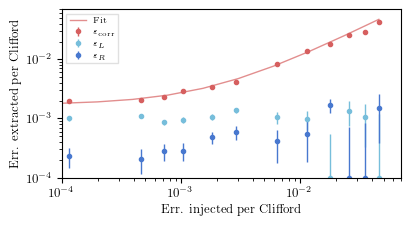

In [7]:
err_inj = 2.17/3 * errs**2
x_fit = np.logspace(-4, np.log10(max(err_inj)), 10)
I_fit = popt[0] + x_fit

fig_width = gs.get_fig_width()*3/4
fig_height = gs.get_fig_width()*3/8

fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))

ax.errorbar(err_inj, [t[0] for t in param1], yerr=[t[1] for t in param1], fmt="o", label="$\\varepsilon_\\mathrm{corr}$", color=gs.get_color(2))
ax.errorbar(err_inj, [t[0] for t in param2], yerr=[t[1] for t in param2], fmt="o", label="$\\varepsilon_L$", color=gs.get_color(5))
ax.errorbar(err_inj, [t[0] for t in param3], yerr=[t[1] for t in param3], fmt="o", label="$\\varepsilon_R$", color=gs.get_color(6))
ax.plot(x_fit, I_fit, color=gs.get_color(2), alpha=gs.get_alpha(), linestyle="-", label="Fit")

ax.set_ylabel("Err. extracted per Clifford")
ax.set_xlabel("Err. injected per Clifford")
ax.legend(loc="upper left")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 7e-2)
ax.set_xlim(1e-4, 7e-2)
# turn off grid
ax.grid(False)


#save the figure
f_path = "..\\..\\pdf_figure\\ch4\\phase_jitter.pdf"
# UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
# fig.savefig(f_path, bbox_inches="tight")


<ErrorbarContainer object of 3 artists>

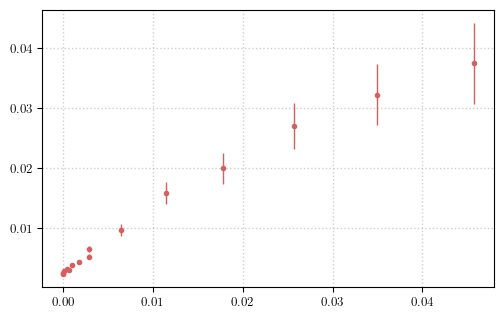

In [43]:
# Fit single qubit decay curves
# Plot single qubit decays
param1_arr, param2_arr = m.fit_mult_1q_rbs(date, rids, sim_outcomes)

plt.errorbar(err_inj, [t[0] for t in param1_arr], yerr=[t[1] for t in param1_arr], fmt="o", label="$\\varepsilon_\\mathrm{L}$", color=gs.get_color(2))

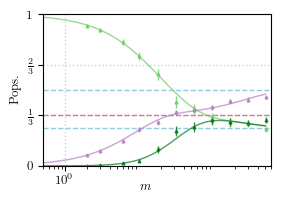

In [28]:

rid = 88863
sim_outcomes = [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, ]
df, popt, pcov = m.rb_to_fits(date, rid, sim_outcomes)
fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
plot_data_fit(ax, df, m, popt)
# x, P_L, P_L_err, P_R, P_R_err = m.get_single_qubit_pops(df)
# popt, pcov = curve_fit(
#     m.single_qubit_model,
#     x,
#     P_L,
#     sigma=P_L_err,
#     p0=[0.01, 0.01],
#     absolute_sigma=True,
# )
# plt.plot(x, P_L, "o", label="Data", color=gs.get_color(2))

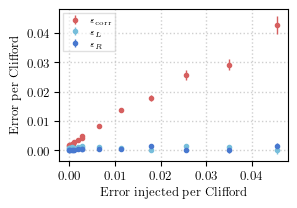

In [ ]:

fig_width = gs.get_fig_width()*246/510*1.05
fig_height = gs.get_fig_width()*246/510*0.7

fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))

err_inj = 2.17/3 * errs**2

ax.errorbar(err_inj, [t[0] for t in param1], yerr=[t[1] for t in param1], fmt="o", label="$\\varepsilon_\\mathrm{corr}$", color=gs.get_color(2))
ax.errorbar(err_inj, [t[0] for t in param2], yerr=[t[1] for t in param2], fmt="o", label="$\\varepsilon_L$", color=gs.get_color(5))
ax.errorbar(err_inj, [t[0] for t in param3], yerr=[t[1] for t in param3], fmt="o", label="$\\varepsilon_R$", color=gs.get_color(6))

ax.set_ylabel("Error per Clifford")
ax.set_xlabel("Error injected per Clifford")
ax.legend(loc="upper left")

